# 03 — Performance Analytics & Event Windows

Drawdown analysis, event-window returns, and return distribution analysis.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join('..', '..')))

import pickle, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import norm

from energy_workbook.config import ALL_TICKERS, EQUITY_TICKERS, EVENT_WINDOWS, RF_RATE

VIZ = os.path.abspath(os.path.join('..', 'visualization'))
DATA = os.path.abspath(os.path.join('..', 'data'))

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 11, 'axes.titlesize': 14,
    'figure.facecolor': 'white', 'axes.facecolor': '#FAFAFA',
    'axes.edgecolor': '#CCCCCC', 'axes.grid': True,
    'grid.alpha': 0.3, 'legend.fontsize': 9,
})
MC_COLORS = ['#002B5C','#1A3C6E','#4A86C8','#0070C0','#C89600',
             '#E06C00','#C00000','#008000','#7030A0','#666666']
cmap_rg = LinearSegmentedColormap.from_list('rg', ['#C00000','#FFFFFF','#006100'])

EVENT_BANDS = {
    2: ('2020-02-20','2020-06-30','#FFD6D6','COVID'),
    4: ('2022-02-24','2022-12-31','#FFE6CC','Russia-Ukraine'),
    6: ('2025-06-01','2025-06-30','#FFF0CC','12-Day War'),
    7: ('2026-02-28','2026-04-30','#FFD6D6','Iran Conflict'),
}
def add_events(ax):
    for _, (s, e, c, _) in EVENT_BANDS.items():
        try: ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.15, color=c, zorder=0)
        except: pass

def savefig(fig, name, dpi=180):
    fig.savefig(os.path.join(VIZ, name), dpi=dpi, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    print(f'  saved {name}')

cache_path = os.path.abspath(os.path.join('..', '..', 'data_cache.pkl'))
with open(cache_path, 'rb') as f:
    D = pickle.load(f)
MASTER = D['master']; LOG_RET = D['log_returns']
print('Data loaded')

Data loaded


## 3.1 Drawdown Timeline

  saved 19_drawdown_timeline.png


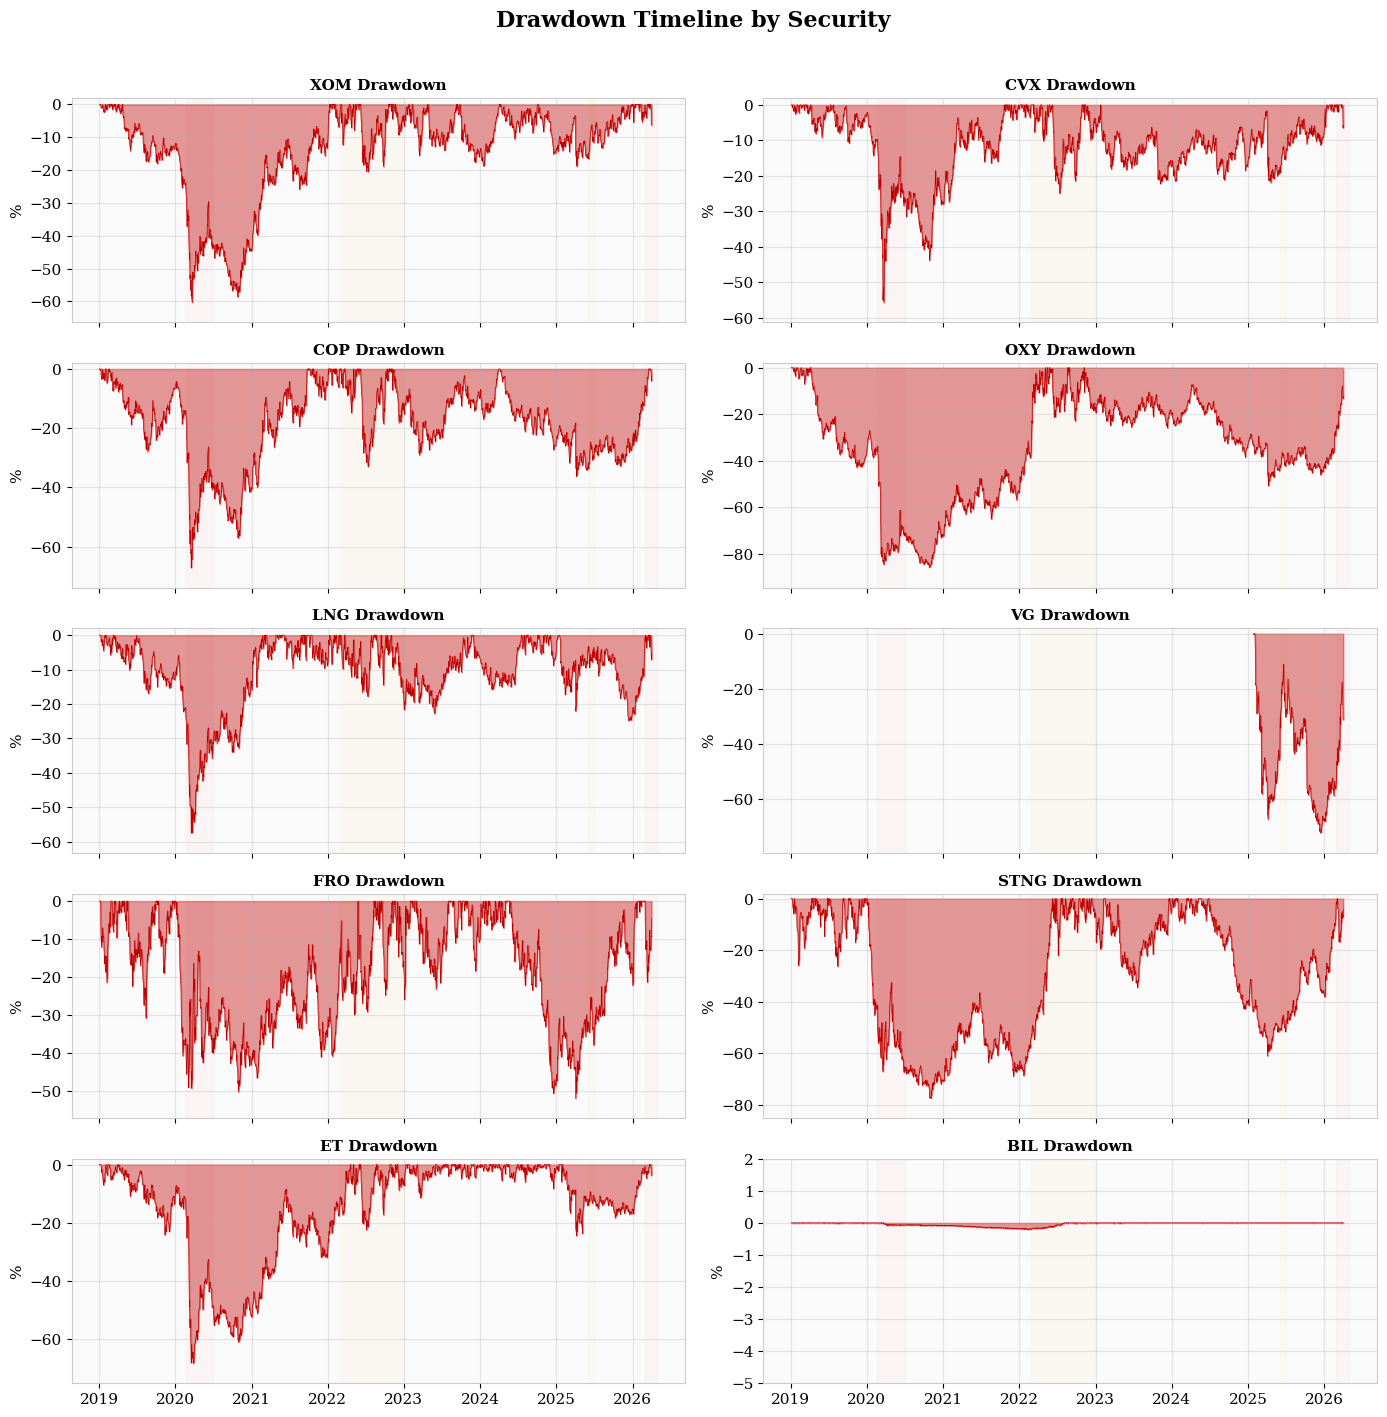

In [2]:
fig, axes = plt.subplots(5, 2, figsize=(14, 14), sharex=True)
axes_flat = axes.flatten()

for i, t in enumerate(ALL_TICKERS):
    ax = axes_flat[i]
    r = LOG_RET.get(t, pd.Series(dtype=float)).dropna()
    if len(r) > 0:
        cum = np.exp(r.cumsum())
        dd = (cum - cum.cummax()) / cum.cummax() * 100
        ax.fill_between(dd.index, dd.values, 0, color='#C00000', alpha=0.4)
        ax.plot(dd.index, dd.values, color='#C00000', linewidth=0.5)
        add_events(ax)
        ax.set_ylabel('%')
        ax.set_title(f'{t} Drawdown', fontweight='bold', fontsize=11)
        ax.set_ylim(min(dd.min()*1.1, -5), 2)

fig.suptitle('Drawdown Timeline by Security', fontweight='bold', fontsize=16, y=1.01)
fig.tight_layout()
savefig(fig, '19_drawdown_timeline.png')
plt.show()

## 3.2 Event Window Returns Heatmap

  saved 08_event_heatmap.png


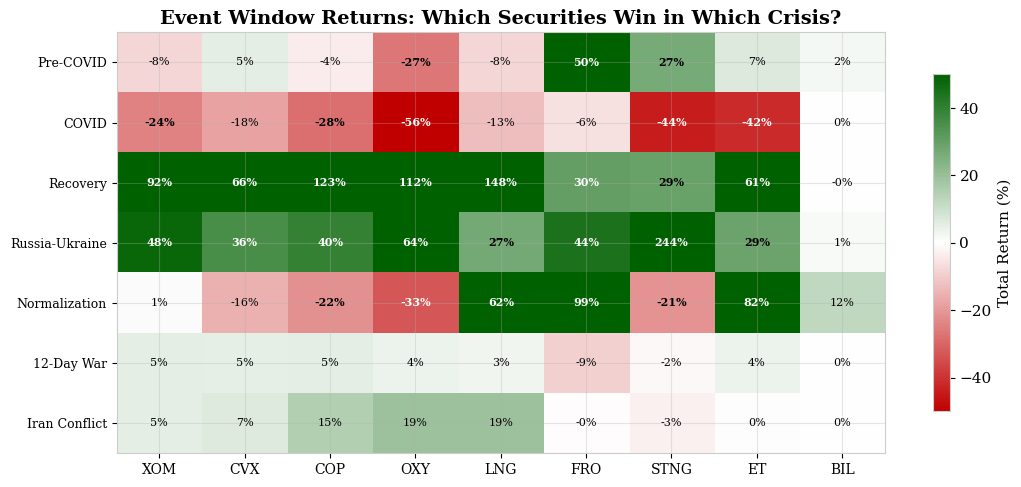

In [3]:
# Compute event returns
event_returns = {}
for eid, (label, start, end) in EVENT_WINDOWS.items():
    event_returns[label] = {}
    for t in ALL_TICKERS:
        r = LOG_RET.get(t, pd.Series(dtype=float))
        er = r[(r.index >= start) & (r.index <= end)].dropna()
        if len(er) > 0:
            event_returns[label][t] = float(np.exp(er.sum()) - 1)

pd.DataFrame(event_returns).to_csv(os.path.join(DATA, 'event_window_returns.csv'))

el = list(event_returns.keys())
et = [t for t in ALL_TICKERS if all(t in event_returns[e] for e in el)]
em = np.array([[event_returns[e].get(t, 0) for t in et] for e in el])

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(em * 100, cmap=cmap_rg, vmin=-50, vmax=50, aspect='auto')
ax.set_xticks(range(len(et))); ax.set_yticks(range(len(el)))
ax.set_xticklabels(et, fontsize=10); ax.set_yticklabels(el, fontsize=9)
for i in range(len(el)):
    for j in range(len(et)):
        v = em[i, j] * 100
        c = 'white' if abs(v) > 30 else 'black'
        ax.text(j, i, f'{v:.0f}%', ha='center', va='center', fontsize=8, color=c,
                fontweight='bold' if abs(v) > 20 else 'normal')
plt.colorbar(im, ax=ax, shrink=0.8, label='Total Return (%)')
ax.set_title('Event Window Returns: Which Securities Win in Which Crisis?', fontweight='bold')
fig.tight_layout()
savefig(fig, '08_event_heatmap.png')
plt.show()

## 3.3 Return Distributions

  saved 20_return_distributions.png


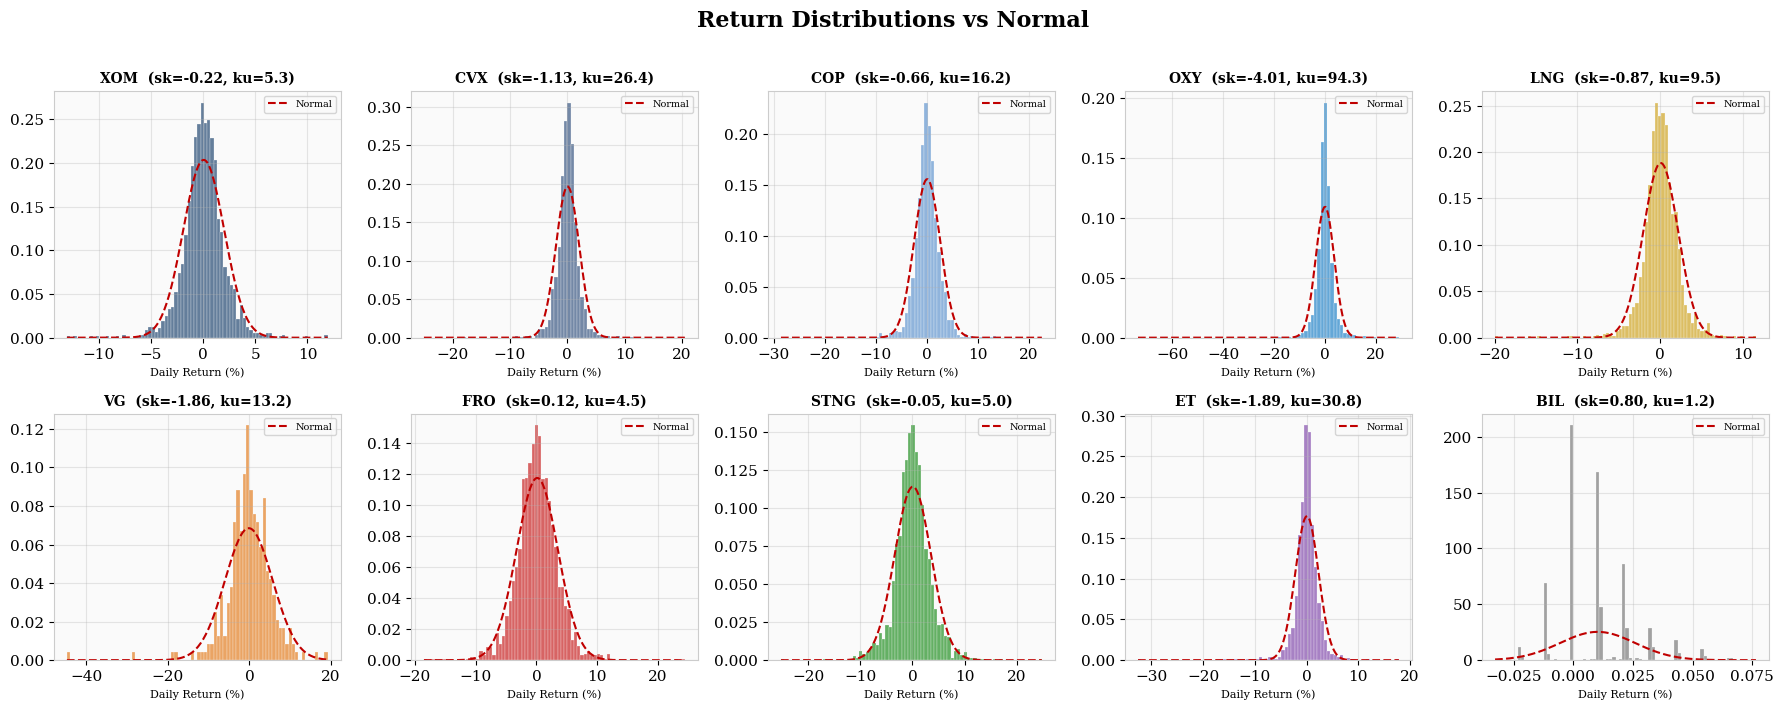

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes_flat = axes.flatten()

for i, t in enumerate(ALL_TICKERS):
    ax = axes_flat[i]
    r = LOG_RET.get(t, pd.Series(dtype=float)).dropna()
    if len(r) > 30:
        ax.hist(r.values * 100, bins=80, density=True, alpha=0.6,
                color=MC_COLORS[i % len(MC_COLORS)], edgecolor='white', linewidth=0.3)
        # Normal overlay
        x_range = np.linspace(r.min() * 100, r.max() * 100, 200)
        ax.plot(x_range, norm.pdf(x_range, r.mean() * 100, r.std() * 100),
                color='#C00000', linewidth=1.5, linestyle='--', label='Normal')
        ax.set_title(f'{t}  (sk={r.skew():.2f}, ku={r.kurtosis():.1f})',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('Daily Return (%)', fontsize=8)
        ax.legend(fontsize=7)

fig.suptitle('Return Distributions vs Normal', fontweight='bold', fontsize=16, y=1.01)
fig.tight_layout()
savefig(fig, '20_return_distributions.png')
plt.show()

## 3.4 Spread Indicators

  saved 14_spread_indicators.png


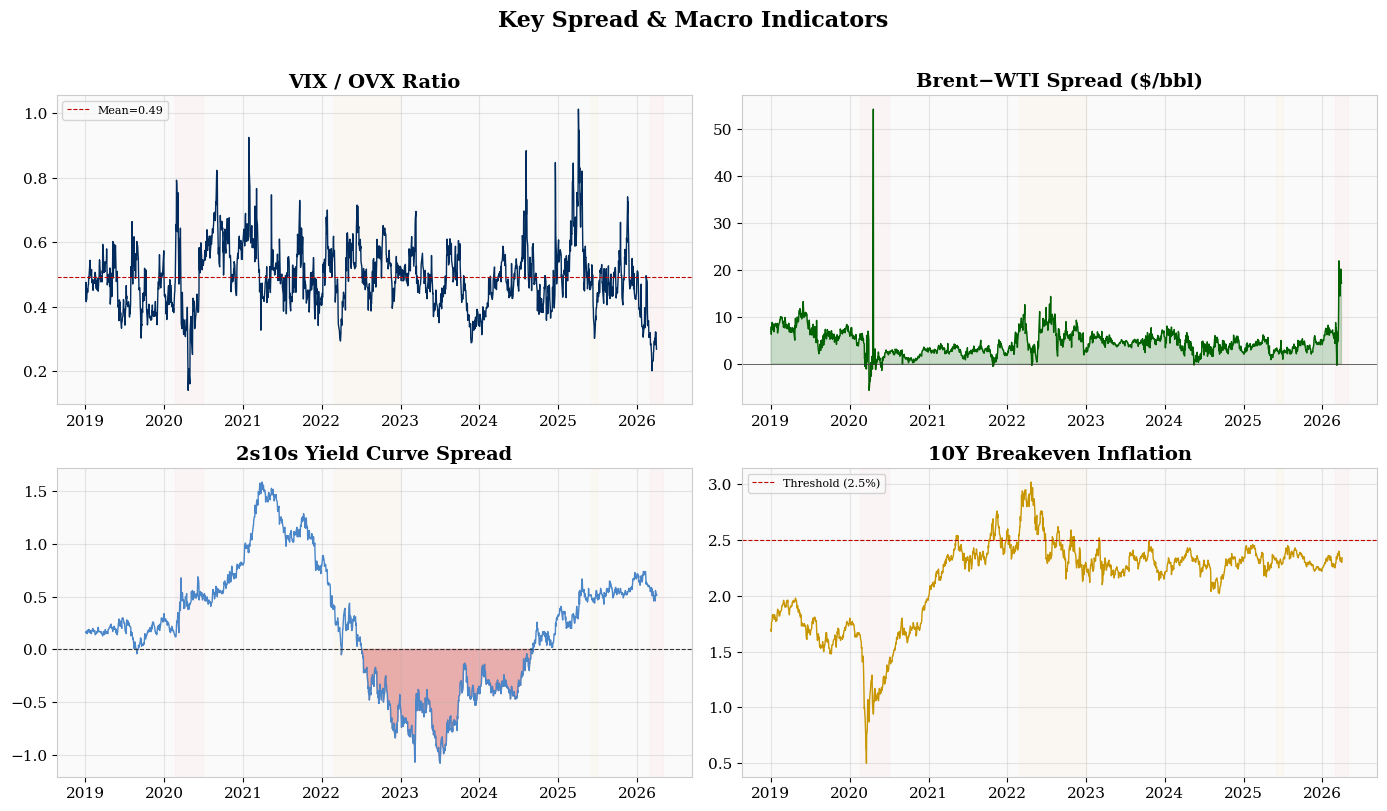

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# VIX/OVX ratio
ax = axes[0,0]
vix = MASTER.get('VIX', pd.Series(dtype=float)).dropna()
ovx = MASTER.get('OVX', pd.Series(dtype=float)).dropna()
common = vix.index.intersection(ovx.index)
ratio = vix[common] / ovx[common]
ax.plot(ratio.index, ratio.values, color='#002B5C', linewidth=1)
ax.axhline(ratio.mean(), color='#C00000', linewidth=0.8, linestyle='--',
           label=f'Mean={ratio.mean():.2f}')
ax.set_title('VIX / OVX Ratio', fontweight='bold')
ax.legend(fontsize=8)
add_events(ax)

# Brent-WTI spread
ax = axes[0,1]
bws = MASTER.get('Brent_WTI_Spread', pd.Series(dtype=float)).dropna()
if len(bws) > 0:
    ax.plot(bws.index, bws.values, color='#006100', linewidth=1)
    ax.fill_between(bws.index, 0, bws.values, where=bws.values>0, alpha=0.2, color='#006100')
    ax.fill_between(bws.index, 0, bws.values, where=bws.values<0, alpha=0.2, color='#C00000')
ax.axhline(0, color='#333', linewidth=0.5)
ax.set_title('Brent−WTI Spread ($/bbl)', fontweight='bold')
add_events(ax)

# 2s10s spread
ax = axes[1,0]
s2s10 = MASTER.get('Spread_2s10s', pd.Series(dtype=float)).dropna()
ax.plot(s2s10.index, s2s10.values, color='#4A86C8', linewidth=1)
ax.fill_between(s2s10.index, 0, s2s10.values, where=s2s10.values<0, alpha=0.3, color='#C00000')
ax.axhline(0, color='#333', linewidth=0.8, linestyle='--')
ax.set_title('2s10s Yield Curve Spread', fontweight='bold')
add_events(ax)

# Breakeven inflation
ax = axes[1,1]
bev = MASTER.get('T10YIE', pd.Series(dtype=float)).dropna()
ax.plot(bev.index, bev.values, color='#C89600', linewidth=1)
ax.axhline(2.5, color='#C00000', linewidth=0.8, linestyle='--', label='Threshold (2.5%)')
ax.set_title('10Y Breakeven Inflation', fontweight='bold')
ax.legend(fontsize=8)
add_events(ax)

fig.suptitle('Key Spread & Macro Indicators', fontweight='bold', fontsize=16, y=1.01)
fig.tight_layout()
savefig(fig, '14_spread_indicators.png')
plt.show()

## 3.5 Monthly Returns Heatmap (COP Example)

  saved 31_monthly_returns_heatmap_cop.png


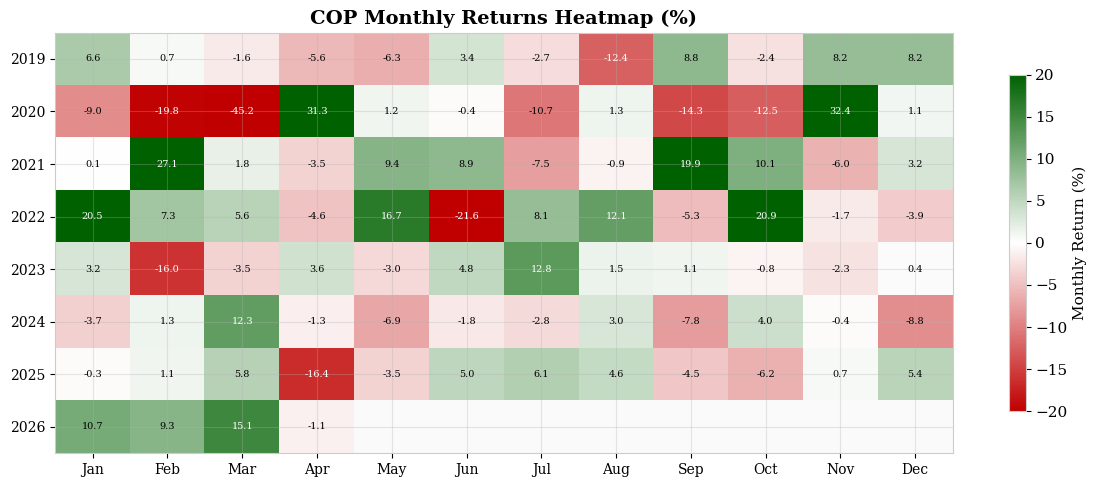

In [6]:
# Monthly returns heatmap for COP
r_cop = LOG_RET.get('COP', pd.Series(dtype=float)).dropna()
monthly = r_cop.resample('ME').sum() * 100
monthly_df = pd.DataFrame({'year': monthly.index.year, 'month': monthly.index.month, 'ret': monthly.values})
pivot = monthly_df.pivot_table(values='ret', index='year', columns='month', aggfunc='first')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][:len(pivot.columns)]

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(pivot.values, cmap=cmap_rg, vmin=-20, vmax=20, aspect='auto')
ax.set_xticks(range(len(pivot.columns))); ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels(pivot.columns, fontsize=10); ax.set_yticklabels(pivot.index, fontsize=10)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        v = pivot.values[i, j]
        if not np.isnan(v):
            c = 'white' if abs(v) > 12 else 'black'
            ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=7, color=c)
plt.colorbar(im, ax=ax, shrink=0.8, label='Monthly Return (%)')
ax.set_title('COP Monthly Returns Heatmap (%)', fontweight='bold')
fig.tight_layout()
savefig(fig, '31_monthly_returns_heatmap_cop.png')
plt.show()